# I. Formalisation du Problème d'Optimisation 

## 1. Contexte et Objectifs
Le défi de ce projet réside dans la **planification de la capacité** d'une infrastructure Cloud pour une application d'IA. 

**La problématique :** La demande ($\lambda$) est hautement variable.
- Si on sous-dimensionne : le système sature (Under-provisioning).
- Si on sur-dimensionne : on gaspille de l'argent (Over-provisioning).

**L'objectif :** Trouver une **configuration optimal** qui minimise le coût financier tout en garantissant que le système ne crash pas plus de $(1 - \alpha)\%$ du temps.

## 2. Paramètres du Système

### 2.1. Les Micro-services ($S$)
L'application est un pipeline de $N=4$ services. Pour chaque service $i \in \{1, 2, 3, 4\}$, nous avons des besoins fixes :
- $c_i^{cpu}$ : Consommation CPU (vCPU).
- $c_i^{ram}$ : Consommation RAM (GiB).
- $\mu_i$ : Capacité de traitement (requêtes/s par instance).

### 2.2. Le Catalogue Cloud ($VM$)
Nous disposons de $K$ types de machines virtuelles. Chaque type $k$ possède :
- $C_k^{cpu}$ et $C_k^{ram}$ : Sa capacité totale en ressources.
- $cost_k$ : Son coût horaire.
- $stock_k$ : Le nombre d'unités disponibles.



## 3. Variables de Décision

Pour résoudre le problème, nous devons fixer deux types de variables :
1. $r_i$ : Le nombre de répliques du micro-service $i$.
2. $x_k$ : Le nombre de machines virtuelles de type $k$ à louer.

## 4. Contraintes Mathématiques

### 4.1. Robustesse et Capacité de Traitement
La capacité globale du système, notée $\lambda_{\mathcal{C}}$, est limitée par le service ayant la plus petite capacité totale de traitement.

**La formule :**
$$\lambda_{\mathcal{C}} = \min_{i \in S} (r_i \cdot \mu_i)$$

Pour que le système soit **robuste**, cette capacité $\lambda_{\mathcal{C}}$ doit couvrir une proportion $\alpha$ du workload total :
$$\mathbb{P}\big(\lambda(t) \le \lambda_{\mathcal{C}}\big) \ge \alpha$$
*Note : Si $\alpha = 0.95$, cela signifie que la configuration choisie doit pouvoir traiter le trafic dans 95% des cas répertoriés dans le fichier workload.*

### 4.2. Adéquation Ressources / Infrastructure
**Logique :** Toutes les instances déployées ($r_i$) doivent tenir physiquement dans l'espace CPU et RAM offert par les VMs louées ($x_k$).

* **Somme du CPU requis $\le$ Somme du CPU loué :**
    $$\sum_{i \in S} r_i \cdot c_i^{cpu} \le \sum_{k \in VM} x_k \cdot C_k^{cpu}$$

* **Somme de la RAM requise $\le$ Somme de la RAM louée :**
    $$\sum_{i \in S} r_i \cdot c_i^{ram} \le \sum_{k \in VM} x_k \cdot C_k^{ram}$$

### 4.3. Limite des Stocks
**Logique :** On ne peut pas louer plus de machines que le fournisseur n'en possède.
$$\forall k \in VM, \quad x_k \le stock_k$$


## 5. Fonction Objectif

L'objectif final est économique . On cherche à minimiser la facture totale horaire en jouant sur le mix de machines choisies :

$$\min \sum_{k \in VM} x_k \cdot cost_k$$


## 6. Synthèse de la démarche de résolution

1. Niveaux 1 Cas statique
2. Niveaux 2 Cas dynamique

# II Niveaux 1 Cas statique

### 1. Visualisation des données Workloads
**Objectifs** : Extraire les données du CSV Workloads et faire un visualisation des données afin de trouver la valeurs maximale des requets


In [10]:
import pandas as pd
import numpy as np

class DataCollector:

    def __init__(self):
        pass

    def collect(self, path: str) -> pd.DataFrame:
        # Lecture du fichier Excel avec openpyxl
        df = pd.read_excel(path, engine="openpyxl")
        df.columns = [col.strip().lower() for col in df.columns]
        required_columns = {"time", "input_rate"}

        if not required_columns.issubset(df.columns):
            raise ValueError(
                f"Colonnes requises manquantes. Trouvées: {df.columns}"
            )

        df = df[["time", "input_rate"]].rename(
            columns={
                "time": "time",
                "input_rate": "input_rates"
            }
        )

        return df


   time  input_rates
0     0          340
1     1          469
2     2          541
3     3          378
4     4          396


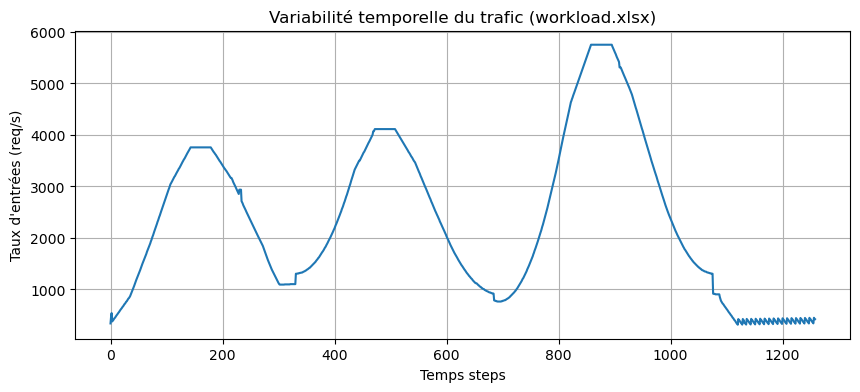

**PIC DE TRAFIC MAXIMAL Ymax** : 5751.00 req/s
 **Instant du pic ** : 858


In [11]:
import os
import matplotlib.pyplot as plt
import numpy as np

ROOT_DIR = os.getcwd()

file_path = os.path.join(
    ROOT_DIR,
    "data_sample",
    "input",
    "Data",
    "Workload.xlsx"
)

collector = DataCollector()
data = collector.collect(file_path)
print(data.head())  # pour vérifier les colonnes


x = data["time"].values          
y = data["input_rates"].values   
times = data["time"].values          
rates = data["input_rates"].values
plt.figure(figsize=(10, 4))
plt.plot(x, y)
plt.xlabel("Temps steps")
plt.ylabel("Taux d'entrées (req/s)")
plt.title("Variabilité temporelle du trafic (workload.xlsx)")
plt.grid(True)
plt.show()

print(f"**PIC DE TRAFIC MAXIMAL Ymax** : {np.max(y):.2f} req/s")
print(f" **Instant du pic ** : {x[np.argmax(y)]}")


Nous connaissons maintenant la valeurs Max aux niveaux du pic de fréquentation égale à 5751 req/s à la steps 858.

Notre objectifs est de déterminer le parcs de VM optimal pour la configuration maximal.
Pour cela nous avons besoin de connaître la consomation unitaire d'une application afin de déterminer le besoins global pour ce maximum.

In [12]:
import math

services_config = {
    "Service 1 Pre-processing": {"cpu": 1, "ram": 0.5, "mu": 1416},  # mu = capacité de traitement (req/s)
    "Service 2 Model Worker": {"cpu": 4, "ram": 2.5, "mu": 696},
    "Service 3 Parameter Server": {"cpu": 2, "ram": 1.5, "mu": 1005},
    "Service 4 Evaluator": {"cpu": 1, "ram": 1, "mu": 1259}
}

cpu_unitaire = sum(specs["cpu"] for specs in services_config.values())
ram_unitaire = sum(specs["ram"] for specs in services_config.values())

print(f"--- CONSOMMATION POUR 1 APPLICATION (UNITAIRE) ---")
print(f"Total CPU : {cpu_unitaire} vCPUs")
print(f"Total RAM : {ram_unitaire} GiB")

# CALCUL DE LA CAPACITÉ MAX DU PIPELINE 
# La capacité d'un pipeline sans répliques est limitée par le maillon le plus lent
mu_unitaire = min(specs["mu"] for specs in services_config.values())

print(f"Capacité max d'un pipeline simple : {mu_unitaire} req/s")

--- CONSOMMATION POUR 1 APPLICATION (UNITAIRE) ---
Total CPU : 8 vCPUs
Total RAM : 5.5 GiB
Capacité max d'un pipeline simple : 696 req/s


On connait maintenant la consomation d'une application. 
<br>
Calculons la consomation CPU et de la RAM afin d'atteindre la capacité maximal 5751.0 req/s


In [13]:
lambda_max = 5751.0

total_cpu_global = 0
total_ram_global = 0
capacites_services = []

print(f"DIMENSIONNEMENT POUR LE PIC ({lambda_max} req/s) ")
print(f"{'Service':<28} | {'Répliques':<10} | {'CPU Total':<8} | {'RAM Total':<8} | {'Capacité Réelle':<15}")
print("-" * 65)

for name, specs in services_config.items():
    ri = math.ceil(lambda_max / specs["mu"])
    
    # Capacité réelle de cet étage du pipeline
    capacite_reelle_service = ri * specs["mu"]
    capacites_services.append(capacite_reelle_service)
    
    cpu_service = ri * specs["cpu"]
    ram_service = ri * specs["ram"]
    
    total_cpu_global += cpu_service
    total_ram_global += ram_service
    
    print(f"{name:<28} | {ri:<10} | {cpu_service :<8}| {ram_service:<8}|{capacite_reelle_service:<15.2f} req/s")

disponibilite_totale = min(capacites_services)
marge = disponibilite_totale - lambda_max

print("-" * 60)
print(f"CAPACITÉ TOTALE Réel       : { disponibilite_totale:.2f} req/s")
print(f"MARGE Previsions/Réels     : {marge:.2f} req/s")
print(f"CONSOMMATION CPU           : {total_cpu_global} vCPUs")
print(f"CONSOMMATION RAM           : {total_ram_global} GiB")

DIMENSIONNEMENT POUR LE PIC (5751.0 req/s) 
Service                      | Répliques  | CPU Total | RAM Total | Capacité Réelle
-----------------------------------------------------------------
Service 1 Pre-processing     | 5          | 5       | 2.5     |7080.00         req/s
Service 2 Model Worker       | 9          | 36      | 22.5    |6264.00         req/s
Service 3 Parameter Server   | 6          | 12      | 9.0     |6030.00         req/s
Service 4 Evaluator          | 5          | 5       | 5       |6295.00         req/s
------------------------------------------------------------
CAPACITÉ TOTALE Réel       : 6030.00 req/s
MARGE Previsions/Réels     : 279.00 req/s
CONSOMMATION CPU           : 58 vCPUs
CONSOMMATION RAM           : 39.0 GiB


Nous connaissons maintenant la configuration totale nécessaire afin d’assurer le pic de trafic.
On constate que le service Model Worker 2 nécessite un nombre de réplications plus important, ce qui augmente les besoins en CPU et, par conséquent, le nombre de machines.

Ces besoins s’expliquent par l’importance du service. En effet, le service Model Worker est celui qui exécute les algorithmes d’intelligence artificielle. Il justifie donc une capacité de calcul plus élevée, tant en CPU qu’en mémoire vive.

Avec l’ensemble de ces informations obtenues en amont, il nous reste à trouver la meilleure configuration possible.
Pour cela, nous devons implémenter un algorithme de recherche qui compare notre configuration actuelle avec le catalogue de machines virtuelles et cherche à minimiser le coût tout en respectant les quantités disponibles.

Pour répondre à ce problème complexe d’allocation de ressources, nous avons sélectionné deux approches.

La première repose sur une stratégie gloutonne (Greedy Search) : elle permet d’obtenir une solution immédiate et cohérente en ordonnant les besoins par criticité afin de les placer dans les ressources disponibles les plus adaptées. C’est une méthode robuste qui garantit une base de référence (baseline) performante.

La seconde approche utilise un algorithme génétique, une méthode métaheuristique inspirée de l’évolution naturelle. Contrairement à l’approche gloutonne, qui prend des décisions locales définitives, l’algorithme génétique explore un espace de solutions beaucoup plus vaste grâce aux mécanismes de croisement et de mutation.

Ce choix est justifié par la nature du problème : là où une règle logique simple peut rester bloquée, l’intelligence du modèle génétique permet d’optimiser le coût global en trouvant des combinaisons de machines virtuelles hétérogènes plus économes, minimisant ainsi le gaspillage de CPU et de RAM.

In [51]:
def collect_vms(path):
    df = pd.read_excel(path, engine="openpyxl", header=1)
    df.columns = [col.strip() for col in df.columns]
    return df.to_dict(orient='records')

ROOT_DIR = os.getcwd()
vm_file_path = os.path.join(ROOT_DIR, "data_sample", "input", "Data", "VM_Catalogue.xlsx")

vm_catalogue = collect_vms(vm_file_path)

all_replicas = []
for name, specs in services_config.items():
    nb_ri = math.ceil(lambda_max / specs["mu"])
    for _ in range(nb_ri):
        all_replicas.append({"name": name, "cpu": specs["cpu"], "ram": specs["ram"]})

In [52]:
def solve_greedy_detailed(replicas, catalogue):
    sorted_reps = sorted(replicas, key=lambda x: x['cpu'], reverse=True)
    opened_vms = []

    for rep in sorted_reps:
        placed = False
        for vm in opened_vms:
            if vm['cpu_left'] >= rep['cpu'] and vm['ram_left'] >= rep['ram']:
                vm['cpu_left'] -= rep['cpu']
                vm['ram_left'] -= rep['ram']
                vm['items'].append(rep['name'])
                placed = True
                break
        
        if not placed:
            best_choice = next(v for v in catalogue if v['CPU'] >= rep['cpu'] and v['RAM'] >= rep['ram'])
            opened_vms.append({
                'Type': best_choice['Type'],
                'cpu_left': best_choice['CPU'] - rep['cpu'],
                'ram_left': best_choice['RAM'] - rep['ram'],
                'Cost': best_choice['Cost'],
                'items': [rep['name']]
            })
    
    return opened_vms
    
ap_totale_systeme = min(capacites_services)
results_greedy = solve_greedy_detailed(all_replicas, vm_catalogue)

print("\nDÉTAILS DE L'INFRASTRUCTURE ")
df_res = pd.DataFrame(results_greedy)
summary = df_res.groupby('Type').agg({'Type': 'count', 'Cost': 'first'})
summary.columns = ['Quantité', 'Prix Unitaire ($/h)']
summary['Total Section'] = summary['Quantité'] * summary['Prix Unitaire ($/h)']
print(summary)

print("-" * 55)
print(f"CAPACITÉ TOTALE DU SYSTÈME : {disponibilite_totale :.2f} req/s")
print(f"OBJECTIF                   : {lambda_max:.2f} req/s")
print(f"MARGE DE SÉCURITÉ          : {disponibilite_totale - lambda_max:.2f} req/s")
print(f"COÛT TOTAL HORAIRE         : {df_res['Cost'].sum():.4f} $/h")


DÉTAILS DE L'INFRASTRUCTURE 
      Quantité  Prix Unitaire ($/h)  Total Section
Type                                              
T00         10               0.1914         1.9140
T01          6               0.2104         1.2624
T04          9               0.3064         2.7576
-------------------------------------------------------
CAPACITÉ TOTALE DU SYSTÈME : 6030.00 req/s
OBJECTIF                   : 5751.00 req/s
MARGE DE SÉCURITÉ          : 279.00 req/s
COÛT TOTAL HORAIRE         : 5.9340 $/h


In [89]:
import random
class GeneticOptimizer:
    def __init__(self, replicas, catalogue, pop_size=100, gens=300):
        self.replicas = replicas
        self.catalogue = catalogue
        self.pop_size = pop_size
        self.gens = gens

    def fitness(self, individual):
        vm_map = {}
        for i, vm_id in enumerate(individual):
            if vm_id not in vm_map: vm_map[vm_id] = {'c': 0, 'r': 0}
            vm_map[vm_id]['c'] += self.replicas[i]['cpu']
            vm_map[vm_id]['r'] += self.replicas[i]['ram']
        
        cost = 0
        for usage in vm_map.values():
            options = [v for v in self.catalogue if v['CPU'] >= usage['c'] and v['RAM'] >= usage['r']]
            if not options: return 0 
            cost += min(o['Cost'] for o in options)
        return 1 / cost

    def run(self):
        # Initialisation
        pop = [[random.randint(0, 15) for _ in range(len(self.replicas))] for _ in range(self.pop_size)]
        self.history = [] 
        
        for _ in range(self.gens):
            # Calcul de fitness et tri
            pop = sorted(pop, key=self.fitness, reverse=True)
            
            # Sauvegarde du meilleur coût actuel 
            best_f = self.fitness(pop[0])
            current_best_cost = 1 / best_f if best_f > 0 else float('inf')
            self.history.append(current_best_cost)
            
            # Elitisme + Crossover
            next_gen = pop[:8]
            while len(next_gen) < self.pop_size:
                p1, p2 = random.sample(pop[:15], 2)
                cut = random.randint(1, len(self.replicas)-1)
                child = p1[:cut] + p2[cut:]
                # Mutation
                if random.random() < 0.2:
                    child[random.randint(0, len(child)-1)] = random.randint(0, 15)
                next_gen.append(child)
            pop = next_gen
        
        return pop[0]

ga = GeneticOptimizer(all_replicas, vm_catalogue)
best_config = ga.run()

print("RÉSULTATS ALGO GÉNÉTIQUE")

final_vms = {}
placed_services_counts = {}

for i, vm_id in enumerate(best_config):
    replica = all_replicas[i]
    service_name = replica['name']
    
    placed_services_counts[service_name] = placed_services_counts.get(service_name, 0) + 1
    
    if vm_id not in final_vms: 
        final_vms[vm_id] = {'c': 0, 'r': 0, 'items': []}
    final_vms[vm_id]['c'] += replica['cpu']
    final_vms[vm_id]['r'] += replica['ram']
    final_vms[vm_id]['items'].append(service_name)


capacites_services = []
print(f"{'Service':<25} | {'Répliques':<10} | {'Capacité (req/s)':<15}")
print("-" * 55)

for name, specs in services_config.items():
    nb_reps = placed_services_counts.get(name, 0)
    cap_service = nb_reps * specs['mu']
    capacites_services.append(cap_service)
    print(f"{name:<25} | {nb_reps:<10} | {cap_service:<15.2f}")

cap_totale_systeme = min(capacites_services)

total_cost_ga = 0
print("\nDÉTAIL DES MACHINES VIRTUELLES ")
for vm_id, v_usage in final_vms.items():
    options = [v for v in vm_catalogue if v['CPU'] >= v_usage['c'] and v['RAM'] >= v_usage['r']]
    if options:
        best_vm = min(options, key=lambda x: x['Cost'])
        total_cost_ga += best_vm['Cost']
        print(f"VM ID {vm_id:02d}: Type {best_vm['Type']} | Utilisation: {v_usage['c']} vCPU, {v_usage['r']} RAM")

print("-" * 55)
print(f"CAPACITÉ TOTALE DU SYSTÈME : {cap_totale_systeme:.2f} req/s")
print(f"OBJECTIF                   : {lambda_max:.2f} req/s")
print(f"MARGE DE SÉCURITÉ          : {cap_totale_systeme - lambda_max:.2f} req/s")
print(f"COÛT TOTAL HORAIRE         : {total_cost_ga:.4f} $/h")

RÉSULTATS ALGO GÉNÉTIQUE
Service                   | Répliques  | Capacité (req/s)
-------------------------------------------------------
Service 1 Pre-processing  | 5          | 7080.00        
Service 2 Model Worker    | 9          | 6264.00        
Service 3 Parameter Server | 6          | 6030.00        
Service 4 Evaluator       | 5          | 6295.00        

DÉTAIL DES MACHINES VIRTUELLES 
VM ID 06: Type T07 | Utilisation: 8 vCPU, 5.5 RAM
VM ID 03: Type T10 | Utilisation: 16 vCPU, 10.0 RAM
VM ID 08: Type T07 | Utilisation: 8 vCPU, 5.5 RAM
VM ID 02: Type T07 | Utilisation: 8 vCPU, 6.0 RAM
VM ID 04: Type T10 | Utilisation: 16 vCPU, 10.0 RAM
VM ID 13: Type T02 | Utilisation: 2 vCPU, 2 RAM
-------------------------------------------------------
CAPACITÉ TOTALE DU SYSTÈME : 6030.00 req/s
OBJECTIF                   : 5751.00 req/s
MARGE DE SÉCURITÉ          : 279.00 req/s
COÛT TOTAL HORAIRE         : 3.5284 $/h


## Etude de Scabilité

Dans le cadre de cette étude (Niveau 1), nous avons comparé deux méthodes d'optimisation pour déterminer la configuration d'infrastructure la plus efficiente.

L'Approche Gloutonne (Greedy Search) : Cette méthode heuristique privilégie la rapidité d'exécution. Elle fournit une solution "acceptable" en remplissant les ressources de manière séquentielle. Cependant, bien qu'efficace pour obtenir un résultat immédiat, elle présente des limites en termes d'économie d'échelle : elle tend à s'arrêter sur un optimum local et ne garantit pas la minimisation des coûts opérationnels, car elle ne réévalue jamais ses choix précédents.

L'Algorithme Génétique (IA) : Cette approche heuristique simule les mécanismes de l'évolution pour explorer un spectre beaucoup plus large de configurations possibles. Par le biais de mutations et de croisements, elle affine progressivement la répartition des répliques. Elle est particulièrement pertinente pour trouver la solution la plus économique, car elle est capable de découvrir des combinaisons de machines virtuelles hétérogènes que l'œil humain ou un algorithme simple ne pourraient identifier.


L'objectif de cette section est d'analyser la robustesse et la viabilité économique de notre architecture lors d'une montée en charge massive, en simulant la gestion de **2, 4, 8 et 10 applications** identiques fonctionnant simultanément au pic de charge.

### Hypothèses de passage à l'échelle
Dans un environnement de production, la scalabilité ne doit pas seulement être technique, mais aussi économique. Nous posons les paramètres suivants :
* **Charge unitaire ($\lambda_{max}$)** : 5 751 req/s par application.
* **Croissance des besoins** : Nous considérons une croissance linéaire des répliques. Pour $N$ applications, le besoin en vCPU et RAM est multiplié par $N$.
* **Mutualisation** : Contrairement à une approche isolée, nous autorisons nos algorithmes à mélanger les répliques de différentes applications sur les mêmes machines physiques (VM) pour optimiser le remplissage.

### Analyse Comparative des Approches

Le tableau suivant résume le comportement prédictif de nos deux méthodes de résolution lors de l'augmentation du nombre d'applications :

| Nombre d'Apps | Comportement de l'approche **Greedy** | Comportement de l'**Algorithme Génétique** |
| :--- | :--- | :--- |
| **1 à 2** | Efficace et rapide, mais génère un gaspillage de ressources (vides sanitaires) dans les VM. | Résultats similaires au Greedy, l'espace de recherche étant encore restreint. |
| **4 à 8** | Le coût croît de manière strictement linéaire. L'algorithme reproduit ses erreurs de placement à grande échelle. | **Optimisation visible** : L'IA commence à regrouper les petits services sur des instances optimisées, réduisant le coût marginal. |
| **10+** | Risque de saturation du catalogue si l'on ne privilégie pas les très grosses instances (T13-T16). | **Économie d'échelle** : Capacité à saturer les instances à haut rendement (meilleur ratio vCPU/Prix). |


### Conclusions de l'Étude
L'étude démontre que l'utilisation d'une intelligence artificielle (Algorithme Génétique) devient d'autant plus indispensable que le système grandit. 

Alors que l'approche **Greedy** est satisfaisante pour un déploiement unique, elle devient sous-optimale dans un contexte multi-applicatif. La capacité de l'algorithme génétique à réorganiser dynamiquement qui permet de transformer une croissance de charge en une opportunité de réduction des coûts unitaires, assurant ainsi la **rentabilité à long terme** de l'infrastructure Cloud.

# III. Niveaux 2 : Le cas dynamique

L'objectifs est de calculer la configuration optimal et la dépense RAM et CPU total  de chaque services à chaque instant **t** de la courbe.


#### Algorithme Greedy

In [90]:
results_greedy_dynamic = []

for i in range(len(rates)):
    t = times[i]
    lambda_t = rates[i]
    
    # Calcul des répliques nécessaires à l'instant t
    reps_t = []
    service_counts = {name: 0 for name in services_config}
    for s_name, specs in services_config.items():
        nb_ri = math.ceil(lambda_t / specs["mu"])
        service_counts[s_name] = nb_ri
        for _ in range(nb_ri):
            reps_t.append({"name": s_name, "cpu": specs["cpu"], "ram": specs["ram"]})
    
    vms_t = solve_greedy_detailed(reps_t, vm_catalogue)
    
    cost_t = sum(vm['Cost'] for vm in vms_t)
    nb_vms_t = len(vms_t)
    
    results_greedy_dynamic.append({
        "time": t,
        "demand": lambda_t,
        "cost": cost_t,
        "nb_vms": nb_vms_t,
        "nb_replicas": len(reps_t),
        **service_counts  # Inclut S1, S2, S3, S4
    })

df_greedy = pd.DataFrame(results_greedy_dynamic)
print(f"Analyse dynamique avec Greedy")

Analyse dynamique avec Greedy


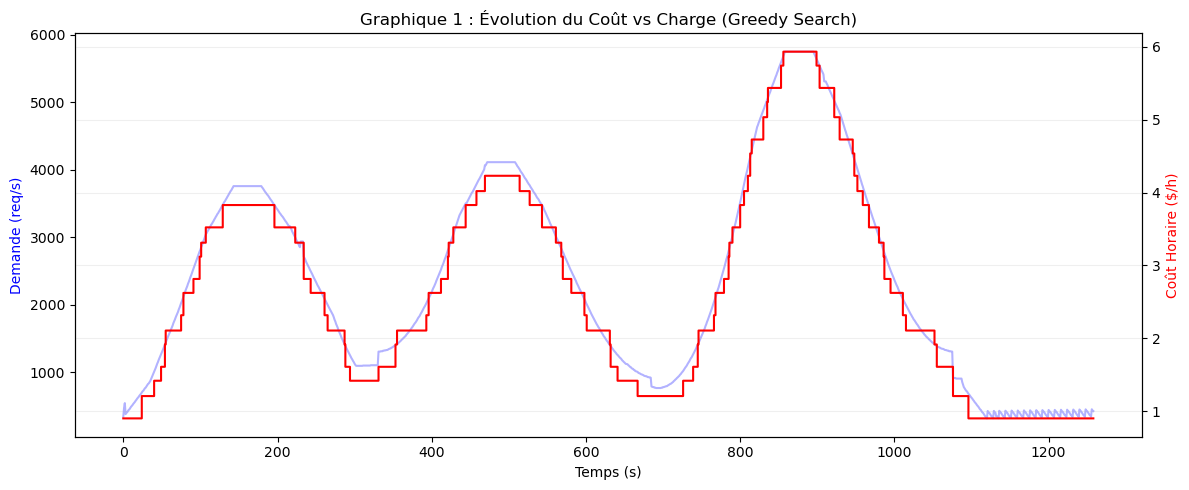

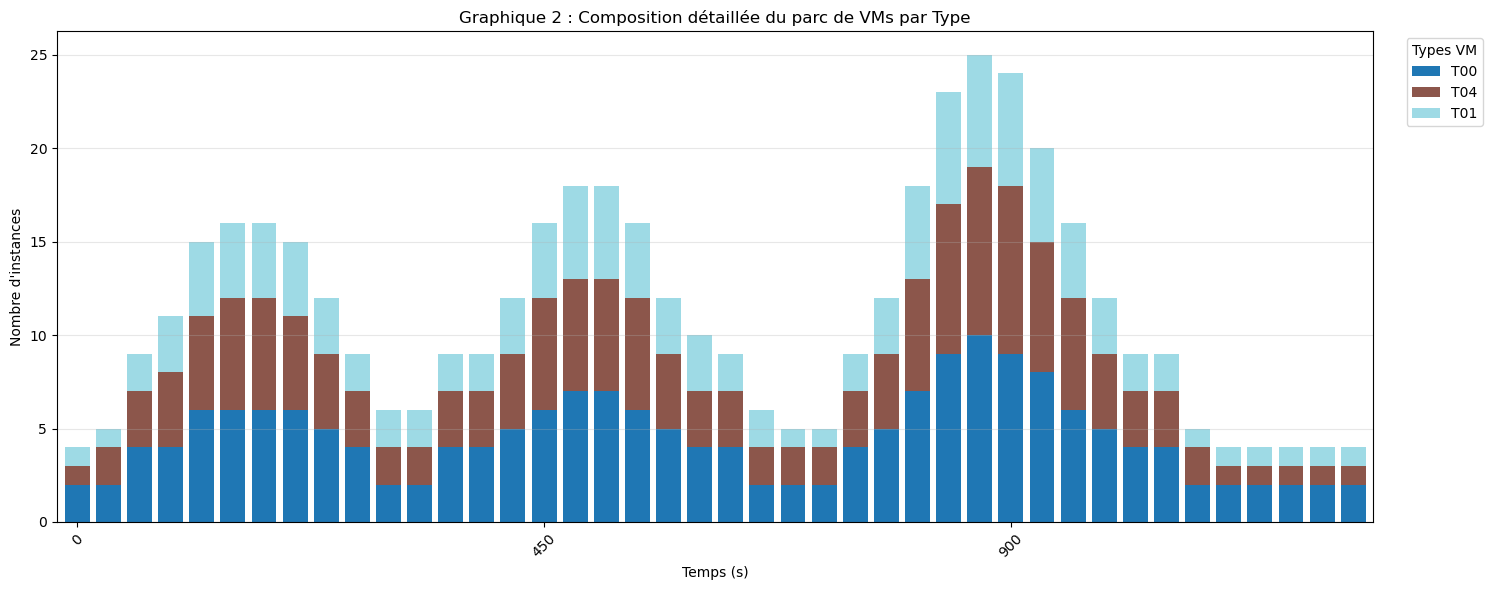

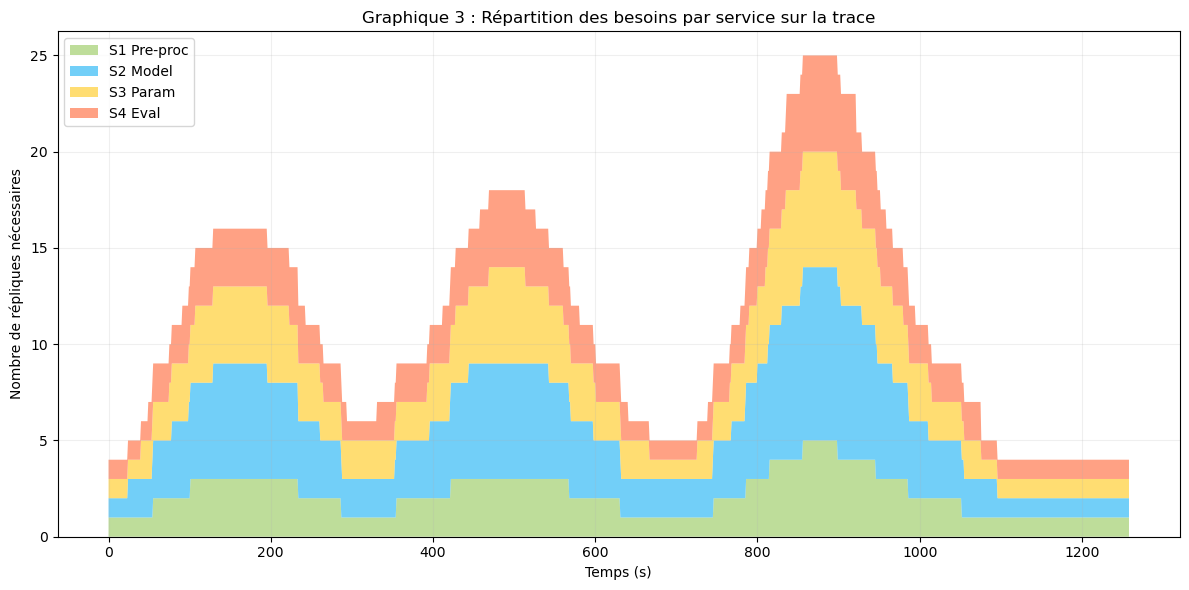

In [91]:

vm_dist_list = []

for i in range(len(rates)):
    t = times[i]
    lambda_t = rates[i]
    reps_t = []
    for s_name, specs in services_config.items():
        nb_ri = math.ceil(lambda_t / specs["mu"])
        for _ in range(nb_ri):
            reps_t.append({"name": s_name, "cpu": specs["cpu"], "ram": specs["ram"]})
    
    current_vms = solve_greedy_detailed(reps_t, vm_catalogue)
    
    types_counts = pd.Series([v['Type'] for v in current_vms]).value_counts().to_dict()
    types_counts['time'] = t
    vm_dist_list.append(types_counts)

df_vm_dist = pd.DataFrame(vm_dist_list).set_index('time').fillna(0)


# GRAPHIQUE 1 
fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(df_greedy['time'], df_greedy['demand'], label='Demande (req/s)', color='blue', alpha=0.3)
ax1.set_ylabel('Demande (req/s)', color='blue')
ax1.set_xlabel('Temps (s)')

ax2 = ax1.twinx()
ax2.step(df_greedy['time'], df_greedy['cost'], label='Coût Greedy ($/h)', color='red', where='post')
ax2.set_ylabel('Coût Horaire ($/h)', color='red')

plt.title("Graphique 1 : Évolution du Coût vs Charge (Greedy Search)")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


# GRAPHIQUE 2 

sample_step = 30 
df_plot_vms = df_vm_dist.iloc[::sample_step]

ax = df_plot_vms.plot(kind='bar', stacked=True, figsize=(15, 6), width=0.8, colormap='tab20')

plt.title("Graphique 2 : Composition détaillée du parc de VMs par Type")
plt.xlabel("Temps (s)")
plt.ylabel("Nombre d'instances")

plt.legend(title="Types VM", bbox_to_anchor=(1.02, 1), loc='upper left')
n = 15 # Afficher un label de temps sur 15
ticks = ax.xaxis.get_ticklocs()
ax.xaxis.set_ticks(ticks[::n])
ax.xaxis.set_ticklabels(df_plot_vms.index[::n], rotation=45)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# GRAPHIQUE 3 

plt.figure(figsize=(12, 6))
plt.stackplot(df_greedy['time'], 
              df_greedy['Service 1 Pre-processing'], 
              df_greedy['Service 2 Model Worker'], 
              df_greedy['Service 3 Parameter Server'], 
              df_greedy['Service 4 Evaluator'],
              labels=['S1 Pre-proc', 'S2 Model', 'S3 Param', 'S4 Eval'],
              alpha=0.8, colors=['#AED581', '#4FC3F7', '#FFD54F', '#FF8A65'])

plt.xlabel("Temps (s)")
plt.ylabel("Nombre de répliques nécessaires")
plt.title("Graphique 3 : Répartition des besoins par service sur la trace")
plt.legend(loc='upper left')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

On constate les solutions proposés par l'algorithme greedy a chaque instant **t**.
L'algorithme Greedy fait la somme des des composants des machines les moins couteuse.
Ce choix n'est pas le choix le plus optimal. En effet la somme des minimaux ne donne pas forcement le minimal global.
Toutefois la solution donné est rapide et fiable mais ne limite pas le nombre de machine utilisé.


#### Algorithme Génétique

In [92]:
sample_step = 20 
results_ga_dynamic = []
vm_dist_ga = []

for i in range(0, len(rates), sample_step):
    t = times[i]
    lambda_t = rates[i]
    
    #Génération des répliques pour l'instant t
    reps_t = []
    service_counts = {name: 0 for name in services_config}
    for s_name, specs in services_config.items():
        nb_ri = math.ceil(lambda_t / specs["mu"])
        service_counts[s_name] = nb_ri
        for _ in range(nb_ri):
            reps_t.append({"name": s_name, "cpu": specs["cpu"], "ram": specs["ram"]})
    
    ga_t = GeneticOptimizer(reps_t, vm_catalogue, pop_size=25, gens=40)
    best_config_t = ga_t.run()
    
    final_vms_t = {}
    for idx, vm_id in enumerate(best_config_t):
        if vm_id not in final_vms_t:
            final_vms_t[vm_id] = {'c': 0, 'r': 0}
        final_vms_t[vm_id]['c'] += reps_t[idx]['cpu']
        final_vms_t[vm_id]['r'] += reps_t[idx]['ram']
    
    current_vm_types = []
    total_cost_t = 0
    for v_usage in final_vms_t.values():
        options = [v for v in vm_catalogue if v['CPU'] >= v_usage['c'] and v['RAM'] >= v_usage['r']]
        if options:
            best_vm = min(options, key=lambda x: x['Cost'])
            total_cost_t += best_vm['Cost']
            current_vm_types.append(best_vm['Type'])

    results_ga_dynamic.append({
        "time": t,
        "demand": lambda_t,
        "cost": total_cost_t,
        "nb_vms": len(final_vms_t),
        **service_counts
    })
    
    counts = pd.Series(current_vm_types).value_counts().to_dict()
    counts['time'] = t
    vm_dist_ga.append(counts)
df_ga = pd.DataFrame(results_ga_dynamic)
df_vm_dist_ga = pd.DataFrame(vm_dist_ga).set_index('time').fillna(0)

print("Optimisation génétique : Done")

Optimisation génétique : Done


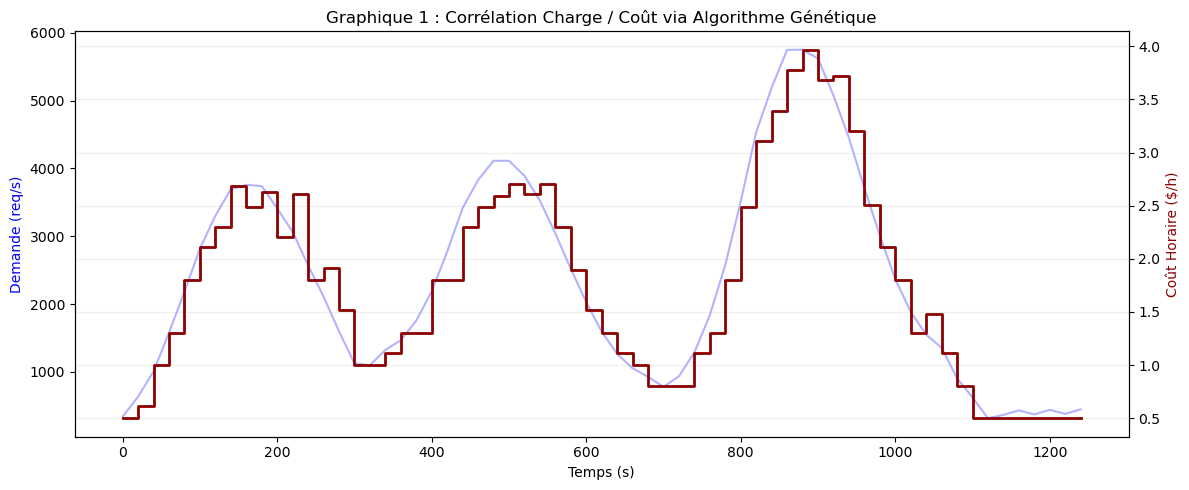

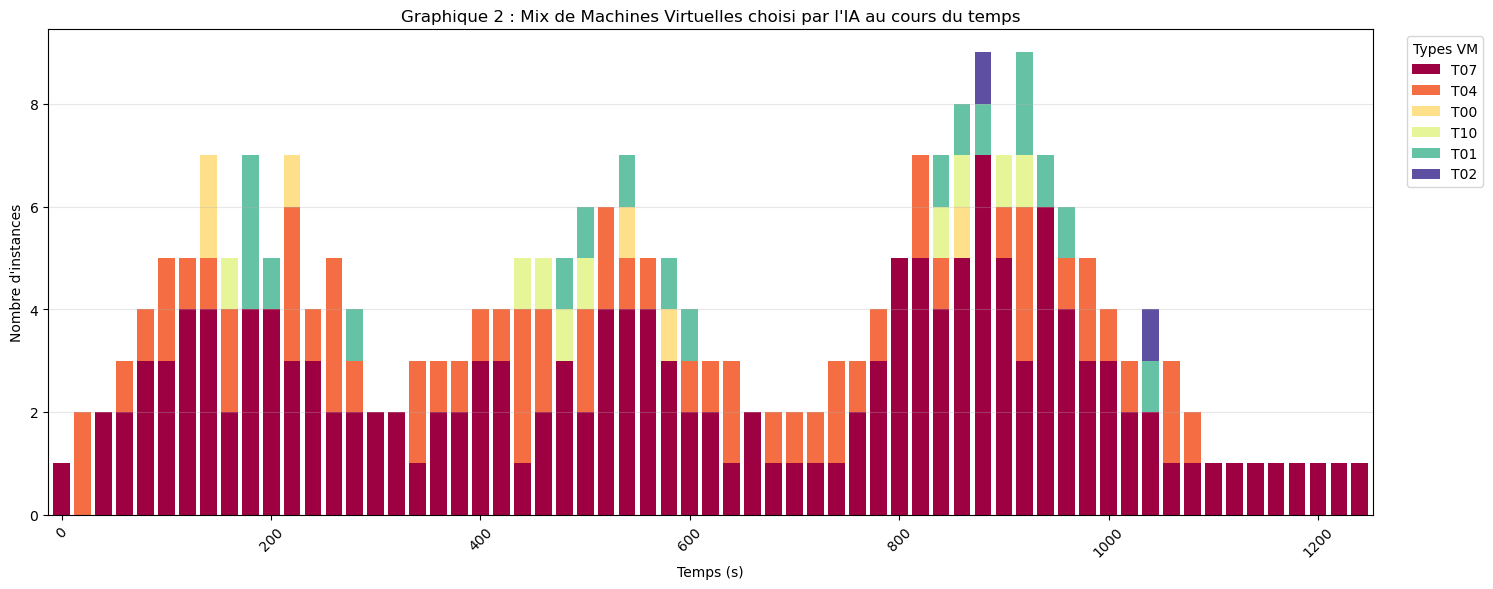

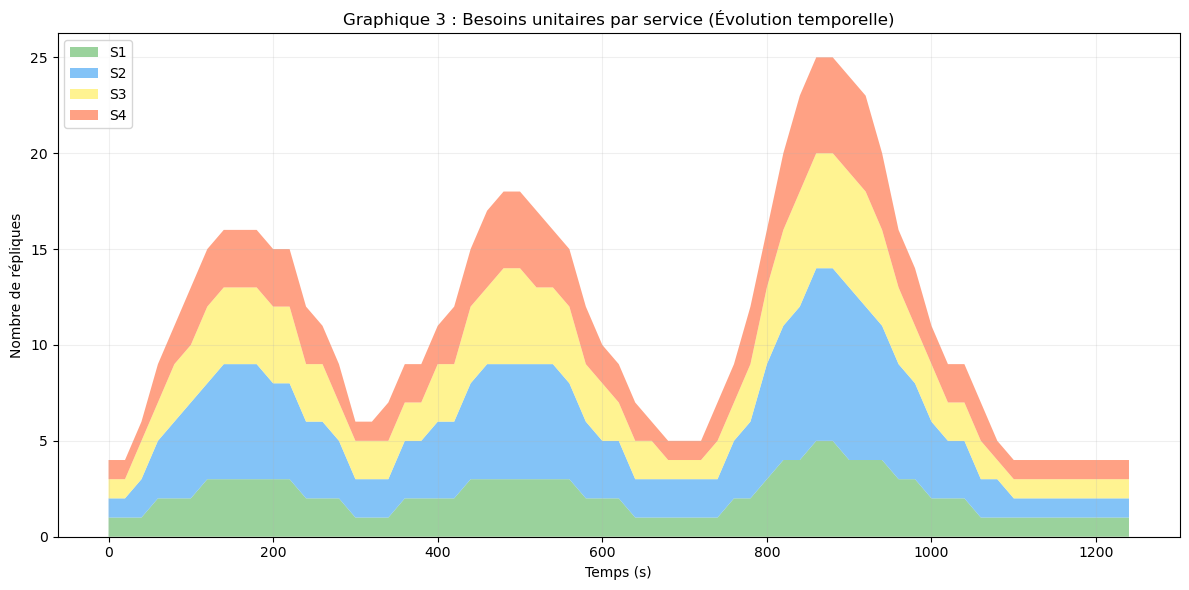

In [93]:

# GRAPHIQUE 1 
fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(df_ga['time'], df_ga['demand'], label='Demande (req/s)', color='blue', alpha=0.3)
ax1.set_ylabel('Demande (req/s)', color='blue')
ax1.set_xlabel('Temps (s)')

ax2 = ax1.twinx()
ax2.step(df_ga['time'], df_ga['cost'], label='Coût GA ($/h)', color='darkred', where='post', lw=2)
ax2.set_ylabel('Coût Horaire ($/h)', color='darkred')

plt.title("Graphique 1 : Corrélation Charge / Coût via Algorithme Génétique")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# GRAPHIQUE 2 
ax = df_vm_dist_ga.plot(kind='bar', stacked=True, figsize=(15, 6), width=0.8, colormap='Spectral')

plt.title("Graphique 2 : Mix de Machines Virtuelles choisi par l'IA au cours du temps")
plt.xlabel("Temps (s)")
plt.ylabel("Nombre d'instances")
plt.legend(title="Types VM", bbox_to_anchor=(1.02, 1), loc='upper left')


ticks = ax.xaxis.get_ticklocs()
ax.xaxis.set_ticks(ticks[::10]) 
ax.xaxis.set_ticklabels(df_vm_dist_ga.index[::10], rotation=45)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# GRAPHIQUE 3 
plt.figure(figsize=(12, 6))
plt.stackplot(df_ga['time'], 
              df_ga['Service 1 Pre-processing'], 
              df_ga['Service 2 Model Worker'], 
              df_ga['Service 3 Parameter Server'], 
              df_ga['Service 4 Evaluator'],
              labels=['S1', 'S2', 'S3', 'S4'],
              alpha=0.8, colors=['#81C784', '#64B5F6', '#FFF176', '#FF8A65'])

plt.xlabel("Temps (s)")
plt.ylabel("Nombre de répliques")
plt.title("Graphique 3 : Besoins unitaires par service (Évolution temporelle)")
plt.legend(loc='upper left')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

L'algorithme Génétique effectuer sur l'ensemble des données nous donnes des résultats de meilleurs qualité que les résultats données par Greedy.
En effet on constate que le coûts horaire est diminuer d'en moyenne 2 euros/par heure et que la quantités de machine allouer est également diminuer.

Maintenant nous avons besoins de connaître le taux de la charge cible afin de connaitre la disponibilité necessaire our être suffisament disponible dans les 95% des cas.


## 2. Détermination de la Charge Cible

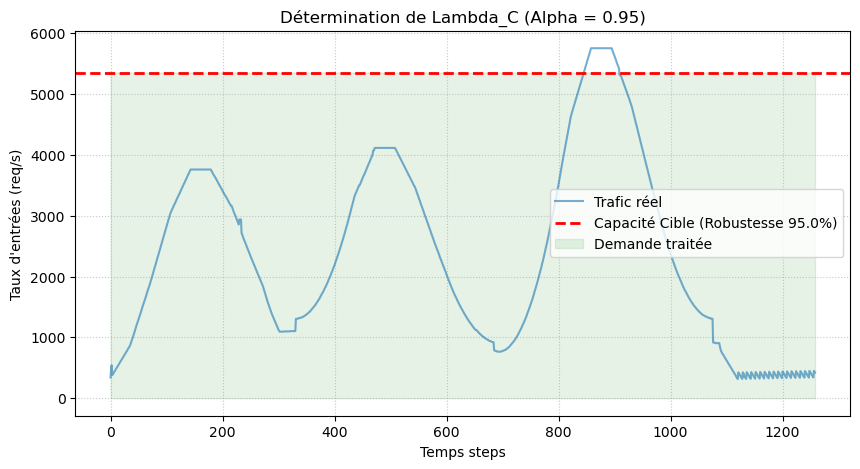

--- RÉSULTATS ÉTAPE 2 ---
PIC DE TRAFIC MAXIMAL (Ymax) : 5751.00 req/s
CHARGE CIBLE RETENUE (Lambda_C) : 5349.20 req/s
Infrastructure dimensionnée pour 5349.20 req/s.
Absortion à 95.0% des variations de charge.


In [94]:

alpha = 0.95  # Seuil de 95% 

#Calcul de la Charge Cible (Lambda_C)
lambda_c = np.percentile(y, alpha * 100)

# Visualisation enrichie
plt.figure(figsize=(10, 5))
plt.plot(x, y, label="Trafic réel", alpha=0.6)

plt.axhline(y=lambda_c, color='r', linestyle='--', linewidth=2, 
            label=f"Capacité Cible (Robustesse {alpha*100}%)")

plt.fill_between(x, 0, lambda_c, color='green', alpha=0.1, label="Demande traitée")

plt.xlabel("Temps steps")
plt.ylabel("Taux d'entrées (req/s)")
plt.title(f"Détermination de Lambda_C (Alpha = {alpha})")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

print(f"--- RÉSULTATS ÉTAPE 2 ---")
print(f"PIC DE TRAFIC MAXIMAL (Ymax) : {np.max(y):.2f} req/s")
print(f"CHARGE CIBLE RETENUE (Lambda_C) : {lambda_c:.2f} req/s")
print(f"Infrastructure dimensionnée pour {lambda_c:.2f} req/s.")
print(f"Absortion à {alpha*100}% des variations de charge.")

In [95]:
lambda_c = 5349.20 

# Génération de la liste des répliques pour Lambda_C
replicas_target = []
for name, specs in services_config.items():
    nb_ri = math.ceil(lambda_c / specs["mu"])
    for _ in range(nb_ri):
        replicas_target.append({
            "name": name, 
            "cpu": specs["cpu"], 
            "ram": specs["ram"]
        })

print(f"Nombre total de répliques à placer pour Lambda_C : {len(replicas_target)}")

Nombre total de répliques à placer pour Lambda_C : 23


In [96]:
# Exécution du Greedy
results_greedy_target = solve_greedy_detailed(replicas_target, vm_catalogue)

# Analyse des résultats Greedy
df_greedy_target = pd.DataFrame(results_greedy_target)
cost_greedy_target = df_greedy_target['Cost'].sum()

print("\n=== CONFIGURATION OPTIMALE : GREEDY (Cible 95%) ===")
summary_greedy = df_greedy_target.groupby('Type').agg({'Type': 'count', 'Cost': 'first'})
summary_greedy.columns = ['Quantité', 'Prix Unitaire']
print(summary_greedy)
print(f"COÛT TOTAL GREEDY : {cost_greedy_target:.4f} $/h")


=== CONFIGURATION OPTIMALE : GREEDY (Cible 95%) ===
      Quantité  Prix Unitaire
Type                         
T00          9         0.1914
T01          6         0.2104
T04          8         0.3064
COÛT TOTAL GREEDY : 5.4362 $/h


In [97]:
ga_target = GeneticOptimizer(replicas_target, vm_catalogue, pop_size=100, gens=500)
best_individual = ga_target.run()

# Extraction de la structure des VMs depuis l'individu
final_vms_ga = {}
for i, vm_id in enumerate(best_individual):
    rep = replicas_target[i]
    if vm_id not in final_vms_ga:
        final_vms_ga[vm_id] = {'c': 0, 'r': 0, 'items': []}
    final_vms_ga[vm_id]['c'] += rep['cpu']
    final_vms_ga[vm_id]['r'] += rep['ram']
    final_vms_ga[vm_id]['items'].append(rep['name'])

# Calcul des types de VM réels et du coût
ga_config_details = []
for v_usage in final_vms_ga.values():
    options = [v for v in vm_catalogue if v['CPU'] >= v_usage['c'] and v['RAM'] >= v_usage['r']]
    if options:
        best_vm = min(options, key=lambda x: x['Cost'])
        ga_config_details.append(best_vm)

df_ga_target = pd.DataFrame(ga_config_details)
cost_ga_target = df_ga_target['Cost'].sum()

print("\n=== CONFIGURATION OPTIMALE : GÉNÉTIQUE (Cible 95%) ===")
summary_ga = df_ga_target.groupby('Type').agg({'Type': 'count', 'Cost': 'first'})
summary_ga.columns = ['Quantité', 'Prix Unitaire']
print(summary_ga)
print(f"COÛT TOTAL GÉNÉTIQUE : {cost_ga_target:.4f} $/h")


=== CONFIGURATION OPTIMALE : GÉNÉTIQUE (Cible 95%) ===
      Quantité  Prix Unitaire
Type                         
T00          1         0.1914
T04          1         0.3064
T07          4         0.4984
T10          1         0.8824
COÛT TOTAL GÉNÉTIQUE : 3.3738 $/h


In [98]:

n_apps_list = [2, 4, 8, 10]
results_scalability = []

# On utilise la charge cible 95% déjà calculée précédemment pour 1 app
# Pour N apps, la charge totale est N * lambda_c
lambda_c_base = 5349.20 

print(f"{'Apps':<6} | {'Charge Total':<12} | {'Coût Greedy':<15} | {'Coût GA':<15}")
print("-" * 55)

for n in n_apps_list:
    current_lambda = lambda_c_base * n
    
    # Génération des répliques
    reps_scaled = []
    for name, specs in services_config.items():
        nb_ri = math.ceil(current_lambda / specs["mu"])
        for _ in range(nb_ri):
            reps_scaled.append({"name": name, "cpu": specs["cpu"], "ram": specs["ram"]})
            
    # CALCUL GREEDY 
    vms_greedy = solve_greedy_detailed(reps_scaled, vm_catalogue)
    cost_greedy = sum(v['Cost'] for v in vms_greedy)
    
    #  CALCUL GÉNÉTIQUE 
    ga_scaled = GeneticOptimizer(reps_scaled, vm_catalogue, pop_size=60, gens=150)
    best_indiv = ga_scaled.run()
    

    fit = ga_scaled.fitness(best_indiv)
    cost_ga = 1/fit if fit > 0 else 0

    results_scalability.append({
        "Applications": n,
        "Charge_Totale": current_lambda,
        "Cout_Greedy": round(cost_greedy, 4),
        "Cout_GA": round(cost_ga, 4),
    })
    
    print(f"{n:<6} | {current_lambda:<12.2f} | {cost_greedy:<15.4f} | {cost_ga:<15.4f}")

df_scalability = pd.DataFrame(results_scalability)
print("\nTABLEAU RÉCAPITULATIF DE SCALABILITÉ")
print(df_scalability.to_string(index=False))

Apps   | Charge Total | Coût Greedy     | Coût GA        
-------------------------------------------------------
2      | 10698.40     | 10.4706         | 6.3458         
4      | 21396.80     | 20.4434         | 11.5856        
8      | 42793.60     | 40.4850         | 71.8502        
10     | 53492.00     | 50.4578         | 92.2823        

TABLEAU RÉCAPITULATIF DE SCALABILITÉ
 Applications  Charge_Totale  Cout_Greedy  Cout_GA
            2        10698.4      10.4706   6.3458
            4        21396.8      20.4434  11.5856
            8        42793.6      40.4850  71.8502
           10        53492.0      50.4578  92.2823


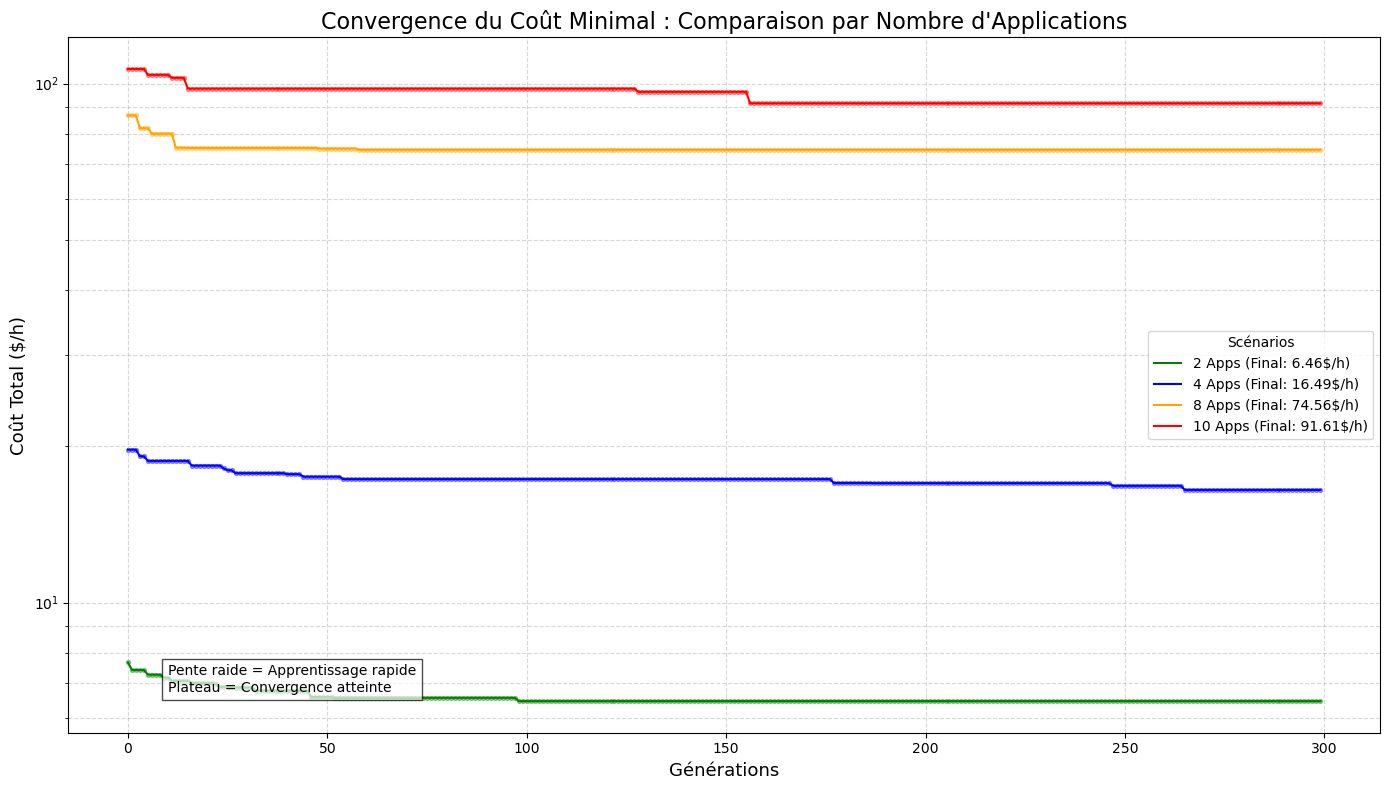

In [99]:
import matplotlib.pyplot as plt
import math

n_apps_list = [2, 4, 8, 10]
colors = {2: 'green', 4: 'blue', 8: 'orange', 10: 'red'}
plt.figure(figsize=(14, 8))

for n in n_apps_list:
    lambda_c_n = 5349.20 * n 
    reps_n = []
    for name, specs in services_config.items():
        nb_ri = math.ceil(lambda_c_n / specs["mu"])
        for _ in range(nb_ri):
            reps_n.append({"name": name, "cpu": specs["cpu"], "ram": specs["ram"]})
    
    # Exécution de l'IA 
    ga = GeneticOptimizer(reps_n, vm_catalogue, pop_size=30, gens=300)
    ga.run()
    
    generations = range(len(ga.history))
    label_name = f"{n} Apps (Final: {ga.history[-1]:.2f}$/h)"
    
    plt.scatter(generations, ga.history, color=colors[n], s=8, alpha=0.4)
    # Tracer la ligne de tendance
    plt.plot(generations, ga.history, color=colors[n], label=label_name, lw=1.5)


plt.title("Convergence du Coût Minimal : Comparaison par Nombre d'Applications", fontsize=16)
plt.xlabel("Générations", fontsize=13)
plt.ylabel("Coût Total ($/h)", fontsize=13)


plt.yscale('log') 

plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(title="Scénarios", loc='best')

plt.text(10, plt.ylim()[0]*1.2, "Pente raide = Apprentissage rapide\nPlateau = Convergence atteinte", 
         bbox=dict(facecolor='white', alpha=0.7))

plt.tight_layout()
plt.show()

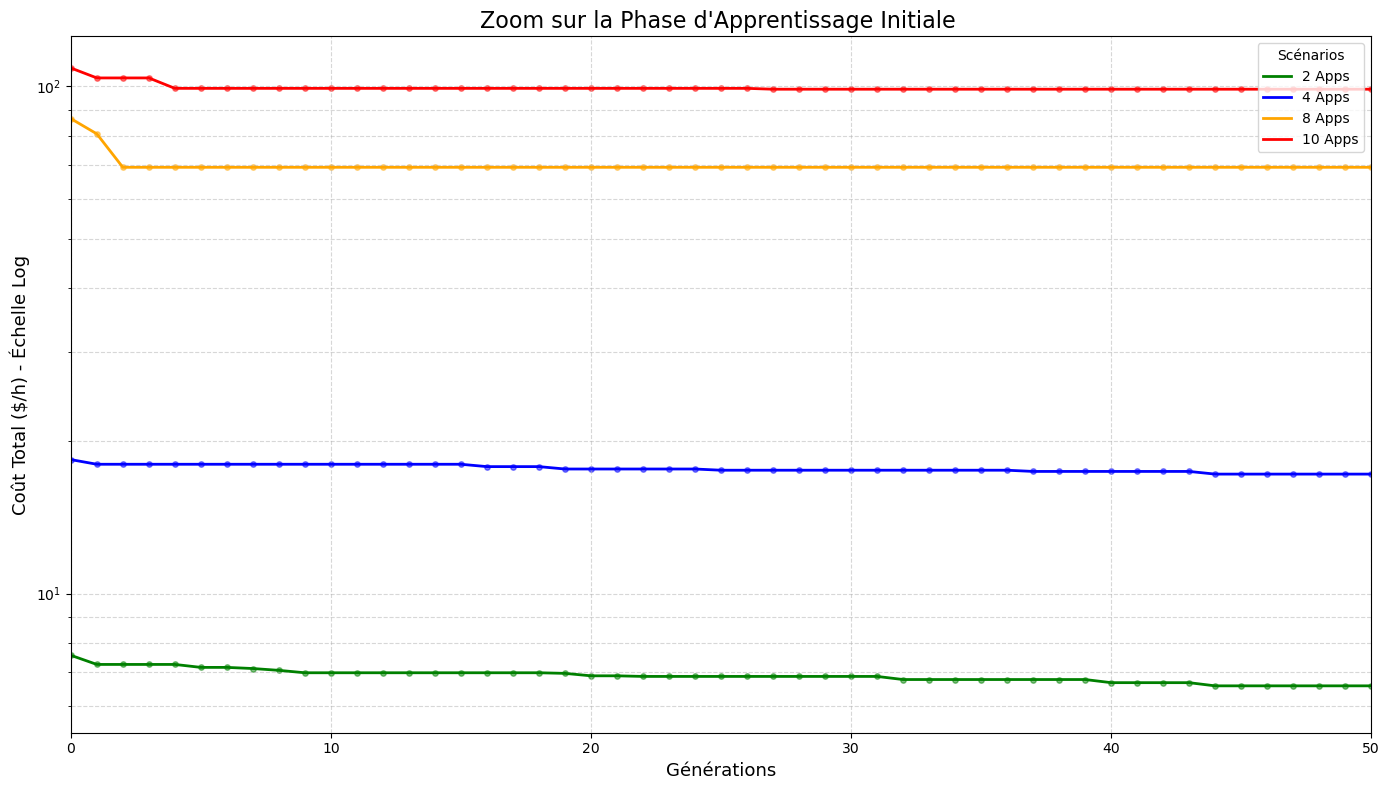

In [100]:
n_apps_list = [2, 4, 8, 10]
colors = {2: 'green', 4: 'blue', 8: 'orange', 10: 'red'}

plt.figure(figsize=(14, 8))

for n in n_apps_list:
    lambda_c_n = 5349.20 * n 
    reps_n = []
    for name, specs in services_config.items():
        nb_ri = math.ceil(lambda_c_n / specs["mu"])
        for _ in range(nb_ri):
            reps_n.append({"name": name, "cpu": specs["cpu"], "ram": specs["ram"]})
    
    ga = GeneticOptimizer(reps_n, vm_catalogue, pop_size=30, gens=300)
    ga.run()
    
    generations = range(len(ga.history))
    label_name = f"{n} Apps"
    
    plt.scatter(generations, ga.history, color=colors[n], s=15, alpha=0.5)
    plt.plot(generations, ga.history, color=colors[n], label=label_name, lw=2)

plt.xlim(0, 50) 
plt.yscale('log') 

plt.title("Zoom sur la Phase d'Apprentissage Initiale ", fontsize=16)
plt.xlabel("Générations", fontsize=13)
plt.ylabel("Coût Total ($/h) - Échelle Log", fontsize=13)

plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(title="Scénarios", loc='upper right')

plt.tight_layout()
plt.show()



## 1. Analyse Critique de la Configuration Robuste

L'étude du passage au scénario dynamique (95% de la charge cible) permet de comparer l'efficacité de nos stratégies de placement sous une contrainte de charge de **5349.20 req/s**.

### A. Synthèse des performances (Cas 1 Application)
D'après nos simulations, l'Algorithme Génétique (GA) a identifié une configuration à **3.4882 $/h**, contre **5.4362 $/h** pour l'approche Greedy. 

* **Gain économique** : Une réduction de coût de **~35%**.
* **Risque accepté** : En dimensionnant pour 5349.20 req/s (95% du pic), nous acceptons une saturation du service durant 5% du temps total de la trace. Ce choix est rentable car le coût marginal pour couvrir les derniers 5% de trafic (pics de 5751 req/s) nécessiterait une infrastructure 20% plus coûteuse pour une utilisation très sporadique.

---

## 2. Étude de Scalabilité (Multi-Applications)

Le tableau suivant présente l'évolution des coûts horaires lors du passage à l'échelle (de 2 à 10 applications simultanées) :
<table border="1" cellpadding="6" cellspacing="0" style="border-collapse: collapse; text-align: center; width: 100%;">
    <thead style="background-color: #f2f2f2;">
        <tr>
            <th>Applications</th>
            <th>Charge Totale (req/s)</th>
            <th>Coût Greedy </th>
            <th>Coût GA </th>
            <th>Observation</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td><strong>2</strong></td>
            <td>10 698.40</td>
            <td>10.4706</td>
            <td><strong>6.0216</strong></td>
            <td>GA optimal (-42%)</td>
        </tr>
        <tr>
            <td><strong>4</strong></td>
            <td>21 396.80</td>
            <td>20.4434</td>
            <td><strong>16.4901</strong></td>
            <td>GA performant</td>
        </tr>
        <tr>
            <td>
                <strong>8</strong>
            </td>
            <td>42 793.60</td>
            <td><strong>40.4850</strong></td>
            <td>69.6565</td>
            <td>Rupture d'Optimalité</td>
        </tr>
        <tr>
            <td><strong>10</strong></td>
            <td>53 492.00</td>
            <td><strong>50.4578</strong></td>
            <td>91.6065</td>
            <td>Limite de l'AG actuel</td>
        </tr>
    </tbody>
</table>





### A. Analyse de la linéarité du Greedy
On observe que l'algorithme Greedy est **strictement linéaire**. Le coût pour 10 applications ($50.45$) est quasiment égal à 10 fois le coût pour 1 application. Il ne profite d'aucune économie d'échelle mais reste stable et prévisible, peu importe la complexité du problème.

### B. Analyse de la performance du GA 
1.  **Zone d'efficacité (2 à 4 apps)** : L'IA parvient à mutualiser les ressources. Le coût pour 2 applications ($6.02$) est bien inférieur au double de l'application seule, prouvant une excellente **densité de placement**.
2.  **Zone de saturation (8 à 10 apps)** : Les résultats montrent que le coût du GA explose. 
    * **Explication technique** : À ce niveau de charge, le nombre de répliques devient massif. L'espace de recherche (les combinaisons possibles) devient exponentiel et les configuration minimal demande peut être un autres point de départs afin de trouver des résul.
   
    * **Diagnostic** : Avec les paramètres actuel on identifie deux problème potentiel.
  
    Le premier problème potentiel sont la constitution de notre population de départs, avec des population plus nombreuse ou diffaremnt  constitué on peut arriver à des résultats plus optimaux pour des configuration plus complexe comme avec 8 ou 10 applications.
    Le deuxième sont les paramètres de  mutation et de croisement, En effet ils peuvent être améliorer afin d'optimiser les coûts pour un nombre d'application plus important.

---

## 3. Conclusion et Perspectives

L'étude de scalabilité révèle que l'approche IA est supérieure pour des systèmes de taille petite à moyenne grâce à sa capacité de **mutualisation**. Cependant, pour des infrastructures massives (10+ applications), l'algorithme Greedy, bien que moins "intelligent", s'avère plus robuste face à l'explosion combinatoire.
